# Hand-eye calibration: one camera or two?

**How you measure the chessboard pose decides how well your robot and cameras line up.**

This notebook accompanies a short explainer video. It rebuilds the whole experiment from scratch on a
**simulated** two-camera robot cell, so every number here can be reproduced with nothing but
`numpy`, `opencv-python`, `scipy` and `matplotlib`.

The setup is a classic *eye-to-hand* cell: two cameras are fixed in the room, and a chessboard is
mounted on the robot flange. We want to know where the cameras are relative to the robot base.

We compare two ways of measuring the chessboard pose in each image pair:

| | Board pose from | Hand-eye solver |
|---|---|---|
| **Typical pipeline** | one camera, `cv2.solvePnP` | `cv2.calibrateHandEye` (Tsai) |
| **Stereo pipeline** | both cameras, triangulate every corner | joint least squares over all poses |

The two are then scored the same way: **leave one pose out, predict it from the robot pose
alone, and measure how far off the prediction lands**.

**Contents**
1. The problem: `A·Y = X·B`
2. A simulated robot cell
3. Measuring the board pose: PnP vs. triangulation
4. Solving hand-eye: Tsai vs. joint least squares
5. The test: leave-one-out
6. When it really matters: a 0.1 % focal-length error
7. Takeaways

## 1. The problem: `A·Y = X·B`

Four transforms connect the robot base to the chessboard (`T_a←b` maps points from frame *b* into frame *a*):

```
            X  (unknown, fixed)                 stereo R, T (known)
  base  ─────────────────────▶  camera 1  ─────────────────────▶  camera 2
    │                               │
    │ A_i  (robot controller)       │ B_i  (measured from images)
    ▼                               ▼
  flange ─────────────────────▶  chessboard
            Y  (unknown, fixed)
```

| Symbol | Transform | Source |
|---|---|---|
| `A_i` | flange → base, `T_base←flange` | robot controller, one per pose |
| `B_i` | board → camera 1, `T_cam1←board` | **measured from the images** |
| `X` | camera 1 → base, `T_base←cam1` | **unknown**, the result we want |
| `Y` | board → flange, `T_flange←board` | **unknown**, a nuisance parameter |

Going around the loop either way must land in the same place, for every pose *i*:

$$A_i \, Y = X \, B_i$$

Every solver uses this equation, so any error in `B_i` goes straight into `X`. The
rest of this notebook is about how to get `B_i` right.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

# One colour per idea, used in every figure
C_TYP, C_OURS = "#e8590c", "#0f9d74"      # typical pipeline, stereo pipeline
C_CAM1, C_CAM2 = "#2f7fd8", "#8a63d2"     # camera identities
C_MID1, C_MID2 = "#f4a582", "#7fcdbb"     # the two "in-between" pipelines


def to_T(R, t):
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = np.ravel(t)
    return T


def inv(T):
    R, t = T[:3, :3], T[:3, 3]
    return to_T(R.T, -R.T @ t)


def apply(T, P):
    return P @ T[:3, :3].T + T[:3, 3]


def rot_deg(R):
    return np.degrees(np.linalg.norm(cv2.Rodrigues(R)[0]))

## 2. A simulated robot cell

The geometry is modelled on a real cell:

* a **9 × 6** inner-corner chessboard with **32 mm** squares on the flange,
* two **2048 × 1536** cameras about **2.3 m** from the board and roughly **90° apart**,
  one from the side and one from overhead,
* **31** robot poses with the board tilted 10–20° around a nominal orientation.

Noise is kept realistic but small:

* corner detection noise of **0.2 px**,
* robot pose noise of **0.15 mm** per axis and **0.01°**, which is typical absolute accuracy for an
  industrial arm.

Because it's a simulation, we know the true `X` and `Y` and can score every method against them.

In [2]:
rng = np.random.default_rng(7)

# ---- chessboard -------------------------------------------------------------------------------
COLS, ROWS, SQUARE_MM = 9, 6, 32.0
OBJP = np.array([[i * SQUARE_MM, j * SQUARE_MM, 0] for j in range(ROWS) for i in range(COLS)], float)
BOARD_CENTER = OBJP.mean(0)

# ---- cameras ----------------------------------------------------------------------------------
IMG_W, IMG_H = 2048, 1536
K_TRUE = {1: np.array([[3500., 0, 1024], [0, 3500., 768], [0, 0, 1]]),
          2: np.array([[3480., 0, 1030], [0, 3480., 760], [0, 0, 1]])}


def look_at(eye, target, up=(0, 0, 1)):
    # Camera -> base transform for an OpenCV camera (x right, y down, z forward).
    z = target - eye; z /= np.linalg.norm(z)
    x = np.cross(z, up); x /= np.linalg.norm(x)
    return to_T(np.column_stack([x, np.cross(z, x), z]), eye)


WORK = np.array([1500., 0, 600])                                  # centre of the robot's work volume, mm
T_BASE_CAM = {1: look_at(WORK + [0, -2300, 400], WORK),            # side camera
              2: look_at(WORK + [350, 250, 2350], WORK, up=(-1, 0, 0))}  # overhead camera
T_CAM2_CAM1 = inv(T_BASE_CAM[2]) @ T_BASE_CAM[1]                  # what stereo calibration gives you

# ---- the two unknowns -------------------------------------------------------------------------
X_TRUE = T_BASE_CAM[1]                                            # camera 1 -> base
Y_TRUE = to_T(Rotation.from_euler("xyz", [180, 0, 25], degrees=True).as_matrix(), [-110, -60, 95])  # board -> flange

# ---- 31 robot poses ---------------------------------------------------------------------------
N_POSES = 31
ROBOT_NOISE_MM, ROBOT_NOISE_DEG = 0.15, 0.01
PIXEL_NOISE = 0.2

view1, view2 = T_BASE_CAM[1][:3, 2], T_BASE_CAM[2][:3, 2]
normal = (view1 + view2) / np.linalg.norm(view1 + view2)          # board faces both cameras


def random_board_pose():
    x = np.cross([0, 0, 1], normal); x /= np.linalg.norm(x)
    R0 = np.column_stack([x, np.cross(normal, x), normal])
    R = Rotation.from_rotvec(rng.normal(size=3) * np.radians([12, 12, 20])).as_matrix() @ R0
    centre = WORK + rng.uniform(-200, 200, 3)
    return to_T(R, centre - R @ BOARD_CENTER)


T_BASE_BOARD = [random_board_pose() for _ in range(N_POSES)]      # ground truth
A_TRUE = [T @ inv(Y_TRUE) for T in T_BASE_BOARD]                  # flange -> base, true
A = [a @ to_T(Rotation.from_rotvec(rng.normal(0, np.radians(ROBOT_NOISE_DEG), 3)).as_matrix(),
              rng.normal(0, ROBOT_NOISE_MM, 3)) for a in A_TRUE]  # what the controller reports
B_TRUE = [inv(X_TRUE) @ T for T in T_BASE_BOARD]                  # board -> camera 1, true

baseline = np.linalg.norm(T_CAM2_CAM1[:3, 3])
angle = np.degrees(np.arccos(view1 @ view2))
dist = np.mean([np.linalg.norm(b[:3, 3]) for b in B_TRUE])
print(f"{N_POSES} poses | stereo baseline {baseline / 1000:.2f} m | cameras {angle:.0f}° apart | "
      f"board ≈ {dist / 1000:.2f} m from camera 1")

31 poses | stereo baseline 3.23 m | cameras 86° apart | board ≈ 2.33 m from camera 1


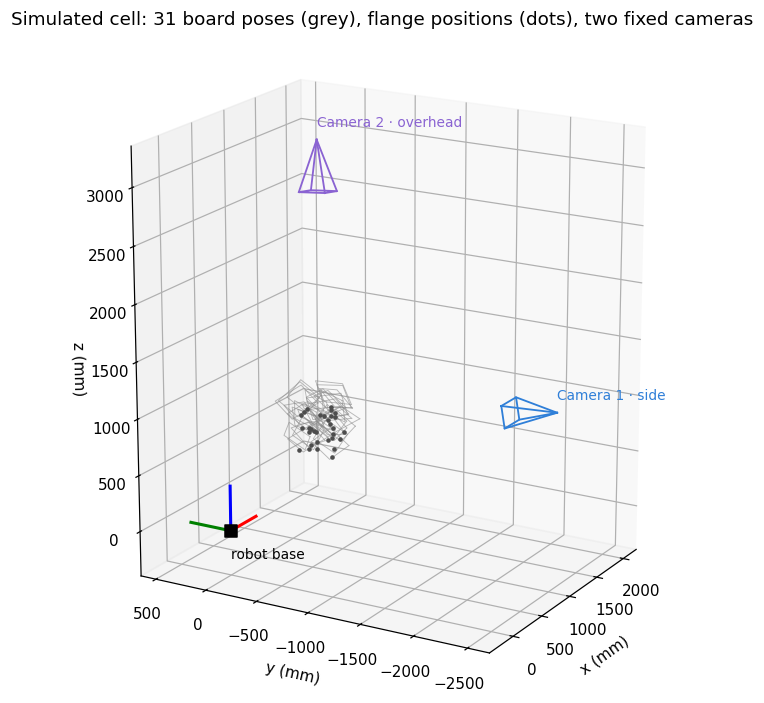

In [3]:
def frustum(T, K, depth=450):
    corners = [(0, 0), (IMG_W, 0), (IMG_W, IMG_H), (0, IMG_H)]
    rays = [np.array([(u - K[0, 2]) / K[0, 0], (v - K[1, 2]) / K[1, 1], 1]) * depth for u, v in corners]
    C, P = T[:3, 3], apply(T, np.array(rays))
    return [np.array([C, p]) for p in P] + [np.vstack([P, P[:1]])]


outline = np.array([[-1, -1, 0], [COLS, -1, 0], [COLS, ROWS, 0], [-1, ROWS, 0], [-1, -1, 0]]) * SQUARE_MM

fig = plt.figure(figsize=(9, 6.5))
ax = fig.add_subplot(projection="3d")
for cam, col, name in [(1, C_CAM1, "Camera 1 · side"), (2, C_CAM2, "Camera 2 · overhead")]:
    for seg in frustum(T_BASE_CAM[cam], K_TRUE[cam]):
        ax.plot(*seg.T, color=col, lw=1.2)
    ax.text(*T_BASE_CAM[cam][:3, 3] + [0, 0, 120], name, color=col, fontsize=9)
for i, T in enumerate(T_BASE_BOARD):
    ax.plot(*apply(T, outline).T, color="0.55", lw=0.6, alpha=0.6)
    ax.scatter(*A[i][:3, 3], s=4, color="0.3")
ax.scatter(0, 0, 0, s=60, color="k", marker="s")
ax.text(0, 0, -250, "robot base", fontsize=9)
for v, c in zip(np.eye(3) * 400, ["r", "g", "b"]):
    ax.plot(*np.array([[0, 0, 0], v]).T, color=c, lw=2)
pts = np.vstack([T_BASE_CAM[1][:3, 3], T_BASE_CAM[2][:3, 3], [0, 0, 0], WORK])
lo, hi = pts.min(0) - 400, pts.max(0) + 400
ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
ax.set_box_aspect(hi - lo)
ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)"); ax.set_zlabel("z (mm)")
ax.view_init(elev=18, azim=-150)
ax.set_title("Simulated cell: 31 board poses (grey), flange positions (dots), two fixed cameras")
plt.tight_layout(); plt.show()

### What the cameras see

We project the 54 corners of every pose into both cameras and add 0.2 px of Gaussian noise. These
"detected corners" are the only image data the rest of the notebook uses, the same as you'd get from
`cv2.findChessboardCorners` + `cornerSubPix` on real images.

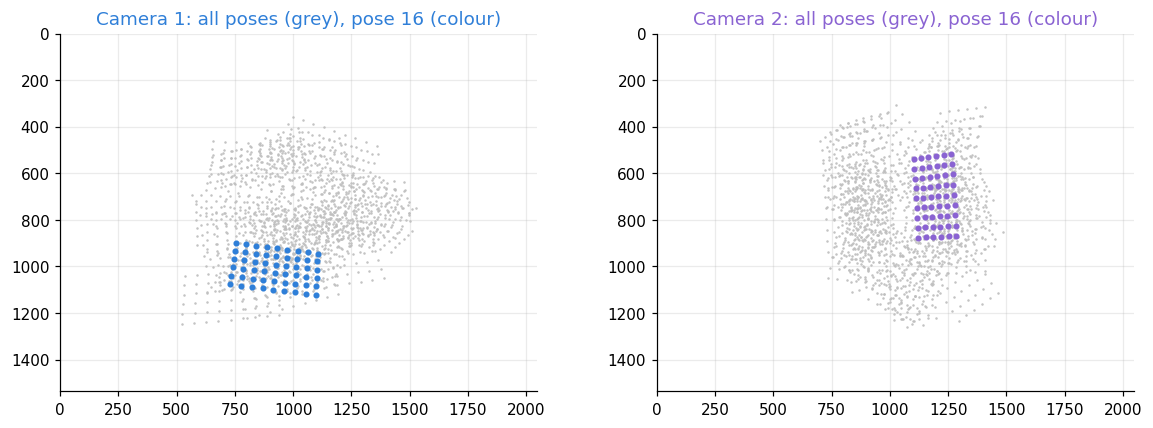

In [4]:
def project(T_cam_board, K):
    p, _ = cv2.projectPoints(OBJP, cv2.Rodrigues(T_cam_board[:3, :3])[0], T_cam_board[:3, 3], K, None)
    return p.reshape(-1, 2)


DETECTED = {cam: [project(inv(T_BASE_CAM[cam]) @ T, K_TRUE[cam]) + rng.normal(0, PIXEL_NOISE, (len(OBJP), 2))
                  for T in T_BASE_BOARD] for cam in (1, 2)}

SHOW = 15  # pose highlighted in the image plot
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
for ax, cam, col in zip(axes, (1, 2), (C_CAM1, C_CAM2)):
    for i in range(N_POSES):
        ax.plot(*DETECTED[cam][i].T, ".", ms=1.2, color="0.75")
    ax.plot(*DETECTED[cam][SHOW].T, "o", ms=3, color=col)
    ax.set_xlim(0, IMG_W); ax.set_ylim(IMG_H, 0); ax.set_aspect("equal")
    ax.set_title(f"Camera {cam}: all poses (grey), pose {SHOW + 1} (colour)", color=col)
plt.tight_layout(); plt.show()

## 3. Measuring the board pose: PnP vs. triangulation

**PnP (one camera).** `cv2.solvePnP` finds the board pose that best explains camera 1's image. That's
reliable sideways, but **weak in depth**. Moving a 30 cm board 1 mm closer at 2.3 m changes its image
by only a fraction of a pixel, so corner noise and any small intrinsics error end up mostly along
the line of sight.

**Triangulation (two cameras).** Each corner is seen by both cameras. Where the two rays cross gives
its 3D position, and the second camera, about 90° off, measures depth directly. We then fit the rigid
board model to the 54 triangulated points (Kabsch / Procrustes).

In [5]:
def pose_pnp(corners1, K1):
    ok, rvec, tvec = cv2.solvePnP(OBJP, corners1, K1, None, flags=cv2.SOLVEPNP_ITERATIVE)
    return to_T(cv2.Rodrigues(rvec)[0], tvec)


def fit_rigid(P, Q):
    # Least-squares rigid transform with Q ≈ R·P + t (Kabsch).
    cp, cq = P.mean(0), Q.mean(0)
    U, _, Vt = np.linalg.svd((P - cp).T @ (Q - cq))
    R = Vt.T @ np.diag([1, 1, np.sign(np.linalg.det(Vt.T @ U.T))]) @ U.T
    return to_T(R, cq - R @ cp)


def pose_stereo(corners1, corners2, K1, K2, T21=T_CAM2_CAM1):
    P1 = K1 @ np.hstack([np.eye(3), np.zeros((3, 1))])
    P2 = K2 @ T21[:3]
    Xh = cv2.triangulatePoints(P1, P2, corners1.T.astype(float), corners2.T.astype(float))
    return fit_rigid(OBJP, (Xh[:3] / Xh[3]).T)


def measure(K_est):
    pnp = [pose_pnp(DETECTED[1][i], K_est[1]) for i in range(N_POSES)]
    stereo = [pose_stereo(DETECTED[1][i], DETECTED[2][i], K_est[1], K_est[2]) for i in range(N_POSES)]
    return {"pnp": pnp, "stereo": stereo}


def depth_split(T_est, T_true):
    # Board-centre error split into along-the-line-of-sight and sideways components (mm).
    c_est, c_true = apply(T_est, BOARD_CENTER[None])[0], apply(T_true, BOARD_CENTER[None])[0]
    d = c_est - c_true
    along = d @ (c_true / np.linalg.norm(c_true))
    return along, np.linalg.norm(d - along * c_true / np.linalg.norm(c_true))


B = measure(K_TRUE)
split = {m: np.array([depth_split(b, bt) for b, bt in zip(B[m], B_TRUE)]) for m in B}
for m, name in [("pnp", "PnP, camera 1"), ("stereo", "Triangulated stereo")]:
    a, s = split[m].T
    print(f"{name:22s} board-centre error RMS: along line of sight {np.sqrt(np.mean(a**2)):.3f} mm, "
          f"sideways {np.sqrt(np.mean(s**2)):.3f} mm")

PnP, camera 1          board-centre error RMS: along line of sight 0.657 mm, sideways 0.026 mm
Triangulated stereo    board-centre error RMS: along line of sight 0.017 mm, sideways 0.021 mm


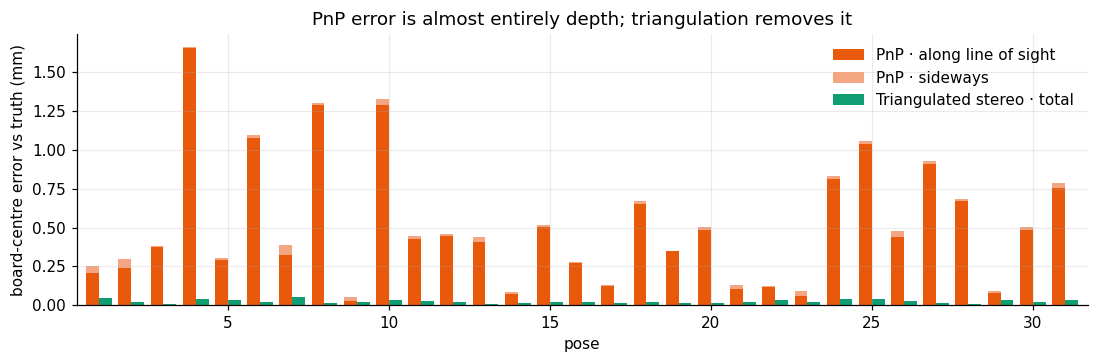

In [6]:
idx = np.arange(1, N_POSES + 1)
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(idx - 0.2, np.abs(split["pnp"][:, 0]), 0.4, color=C_TYP, label="PnP · along line of sight")
ax.bar(idx - 0.2, split["pnp"][:, 1], 0.4, bottom=np.abs(split["pnp"][:, 0]), color=C_MID1, label="PnP · sideways")
ax.bar(idx + 0.2, np.hypot(*split["stereo"].T), 0.4, color=C_OURS, label="Triangulated stereo · total")
ax.set_xlabel("pose"); ax.set_ylabel("board-centre error vs truth (mm)")
ax.set_title("PnP error is almost entirely depth; triangulation removes it")
ax.legend(frameon=False); ax.set_xlim(0.3, N_POSES + 0.7)
plt.tight_layout(); plt.show()

### Why one camera can't catch its own error

PnP fits camera 1's image almost perfectly, because that's what it minimises. The depth error only
shows up when you project the PnP pose into **camera 2**, which looks at the board from the side.
Here is the pose with the largest PnP depth error.

In [7]:
def reproj_rms(T_cam1_board, cam, i, K_est):
    T = T_cam1_board if cam == 1 else T_CAM2_CAM1 @ T_cam1_board
    return np.sqrt(np.mean(np.sum((project(T, K_est[cam]) - DETECTED[cam][i]) ** 2, 1)))


worst = int(np.argmax(np.abs(split["pnp"][:, 0])))
print(f"pose {worst + 1} (PnP depth error {split['pnp'][worst, 0]:+.2f} mm)")
print(f"   reprojection RMS (px)            camera 1   camera 2")
for m, name in [("pnp", "PnP from camera 1"), ("stereo", "Triangulated stereo")]:
    print(f"   {name:30s}  {reproj_rms(B[m][worst], 1, worst, K_TRUE):6.2f}     {reproj_rms(B[m][worst], 2, worst, K_TRUE):6.2f}")

pose 4 (PnP depth error +1.66 mm)
   reprojection RMS (px)            camera 1   camera 2
   PnP from camera 1                 0.28       2.18
   Triangulated stereo               0.30       0.27


## 4. Solving hand-eye: Tsai vs. joint least squares

**Tsai** (`cv2.calibrateHandEye`) is the standard choice. It's a closed-form solver that works on
*relative* motions between pose pairs and first solves rotation, then translation. For an
eye-to-hand cell you pass it the **inverse** robot poses (base → flange), and it returns camera → base.
It doesn't give `Y`, so we average `Y = A_i⁻¹ · X · B_i` over all poses.

**Joint least squares** solves `X` and `Y` together. It minimises the mismatch of `A_i·Y = X·B_i`
over every pose at once, as a 6-DoF rotation + translation residual per pose. That spreads
the noise across all poses instead of carrying it through a chain of pairwise differences. We start
it from the Tsai solution.

In [8]:
def average_T(Ts):
    U, _, Vt = np.linalg.svd(np.mean([T[:3, :3] for T in Ts], 0))
    R = U @ np.diag([1, 1, np.linalg.det(U @ Vt)]) @ Vt
    return to_T(R, np.mean([T[:3, 3] for T in Ts], 0))


def solve_tsai(As, Bs):
    base2flange = [inv(a) for a in As]                       # eye-to-hand: feed the inverse robot poses
    R, t = cv2.calibrateHandEye([g[:3, :3] for g in base2flange], [g[:3, 3] for g in base2flange],
                                [b[:3, :3] for b in Bs], [b[:3, 3] for b in Bs],
                                method=cv2.CALIB_HAND_EYE_TSAI)
    X = to_T(R, t)
    return X, average_T([inv(a) @ X @ b for a, b in zip(As, Bs)])


def _pack(T):
    return np.r_[cv2.Rodrigues(T[:3, :3])[0].ravel(), T[:3, 3]]


def _unpack(v):
    return to_T(cv2.Rodrigues(v[:3])[0], v[3:6])


def solve_least_squares(As, Bs):
    X0, Y0 = solve_tsai(As, Bs)

    def residuals(v):
        X_inv, Y = inv(_unpack(v[:6])), _unpack(v[6:])
        out = []
        for a, b in zip(As, Bs):
            E = inv(b) @ X_inv @ a @ Y                          # identity when A·Y = X·B holds exactly
            out.append(np.r_[cv2.Rodrigues(E[:3, :3])[0].ravel(), E[:3, 3]])
        return np.concatenate(out)

    v = least_squares(residuals, np.r_[_pack(X0), _pack(Y0)], x_scale="jac").x
    return _unpack(v[:6]), _unpack(v[6:])


PIPELINES = {  # name: (board-pose measurement, solver, colour)
    "PnP + Tsai  (typical)":           ("pnp", solve_tsai, C_TYP),
    "PnP + least squares":             ("pnp", solve_least_squares, C_MID1),
    "Stereo + Tsai":                   ("stereo", solve_tsai, C_MID2),
    "Stereo + least squares  (ours)":  ("stereo", solve_least_squares, C_OURS),
}

print(f"{'all 31 poses':34s} camera→base error     board→flange error")
for name, (m, solver, _) in PIPELINES.items():
    X, Y = solver(A, B[m])
    print(f"{name:34s} {np.linalg.norm(X[:3, 3] - X_TRUE[:3, 3]):5.2f} mm {rot_deg(X[:3, :3].T @ X_TRUE[:3, :3]):6.3f}°"
          f"      {np.linalg.norm(Y[:3, 3] - Y_TRUE[:3, 3]):5.2f} mm {rot_deg(Y[:3, :3].T @ Y_TRUE[:3, :3]):6.3f}°")

all 31 poses                       camera→base error     board→flange error
PnP + Tsai  (typical)               1.35 mm  0.002°       1.16 mm  0.006°
PnP + least squares                 0.73 mm  0.014°       0.56 mm  0.016°
Stereo + Tsai                       0.49 mm  0.022°       0.43 mm  0.017°
Stereo + least squares  (ours)      0.39 mm  0.013°       0.12 mm  0.009°


Camera-position errors are larger than the per-pose board errors. That's expected: `X` places a camera
2.3 m away, so a hundredth of a degree of rotation error moves its origin by about half a millimetre. What matters in practice
is whether the calibration **predicts where the board is**, so that's what we test next.

## 5. The test: leave one out, predict it, compare

For each of the 31 poses:

1. calibrate on the **other 30**,
2. predict the held-out board pose from the robot pose alone: `B̂_i = X⁻¹ · A_i · Y`,
3. compare with the truth: **position error** (mm RMS over the 54 corners) and **reprojection error**
   into both images (px RMS).

On real data you don't have ground truth, so the reprojection error into both cameras is the number to
watch. Both are reported here.

In [9]:
def leave_one_out(Bm, solver, K_est):
    mm, px = [], []
    for i in range(N_POSES):
        keep = [j for j in range(N_POSES) if j != i]
        X, Y = solver([A[j] for j in keep], [Bm[j] for j in keep])
        B_pred = inv(X) @ A[i] @ Y
        mm.append(np.sqrt(np.mean(np.sum((apply(B_pred, OBJP) - apply(B_TRUE[i], OBJP)) ** 2, 1))))
        for cam in (1, 2):
            T = B_pred if cam == 1 else T_CAM2_CAM1 @ B_pred
            px.append(np.sqrt(np.mean(np.sum((project(T, K_est[cam]) - DETECTED[cam][i]) ** 2, 1))))
    rms = lambda v: float(np.sqrt(np.mean(np.square(v))))
    return {"mm": rms(mm), "px": rms(px)}


LOO = {name: leave_one_out(B[m], solver, K_TRUE) for name, (m, solver, _) in PIPELINES.items()}
for name, r in LOO.items():
    print(f"{name:34s} held-out error {r['mm']:.3f} mm   {r['px']:.2f} px")

PnP + Tsai  (typical)              held-out error 0.517 mm   0.71 px
PnP + least squares                held-out error 0.321 mm   0.47 px
Stereo + Tsai                      held-out error 0.303 mm   0.47 px
Stereo + least squares  (ours)     held-out error 0.264 mm   0.42 px


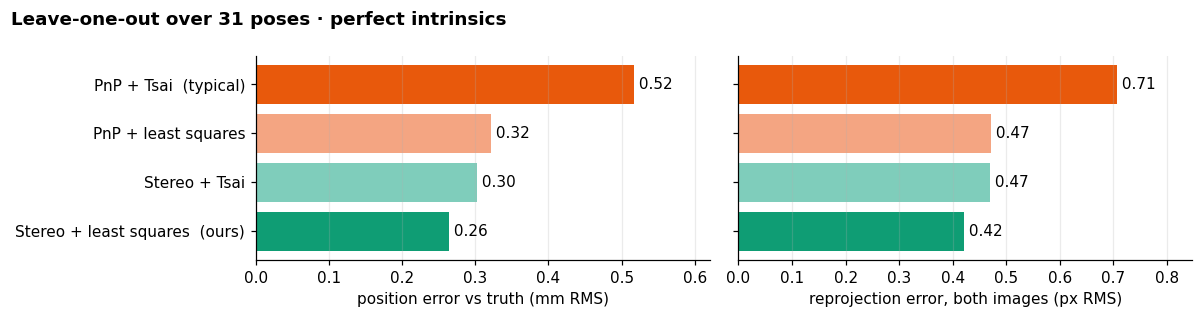

Stereo + least squares: 49% less held-out position error than the typical pipeline


In [10]:
def bar_panel(results, title):
    names = list(PIPELINES)[::-1]
    cols = [PIPELINES[n][2] for n in names]
    fig, axes = plt.subplots(1, 2, figsize=(11, 2.9), sharey=True)
    for ax, key, label in zip(axes, ("mm", "px"), ("position error vs truth (mm RMS)", "reprojection error, both images (px RMS)")):
        vals = [results[n][key] for n in names]
        ax.barh(names, vals, color=cols)
        for y, v in enumerate(vals):
            ax.text(v, y, f" {v:.2f}", va="center")
        ax.set_xlabel(label); ax.set_xlim(0, max(vals) * 1.2); ax.grid(axis="y", visible=False)
    fig.suptitle(title, x=0.01, ha="left", fontweight="bold")
    plt.tight_layout(); plt.show()


bar_panel(LOO, "Leave-one-out over 31 poses · perfect intrinsics")
gain = 1 - LOO["Stereo + least squares  (ours)"]["mm"] / LOO["PnP + Tsai  (typical)"]["mm"]
print(f"Stereo + least squares: {gain:.0%} less held-out position error than the typical pipeline")

Even with **perfect** intrinsics, the stereo pipeline halves the error. What's left
(≈ 0.26 mm) is mostly the robot's own 0.15 mm-per-axis pose noise, a floor that no camera
method can beat.

## 6. When it really matters: a 0.1 % focal-length error

Intrinsic calibration is never perfect. A focal length that's off by **0.1 %** (3.5 px out of 3500) is
a very good calibration. But PnP gets depth from the board's *apparent size*, so a focal-length error
becomes a depth error directly: `0.1 % × 2.3 m ≈ 2.3 mm`, the same on every pose.

Triangulation gets depth from the **angle between two rays**, so it barely notices. Below, we give
camera 1's focal length a small error, rerun everything, and sweep the size of the error.

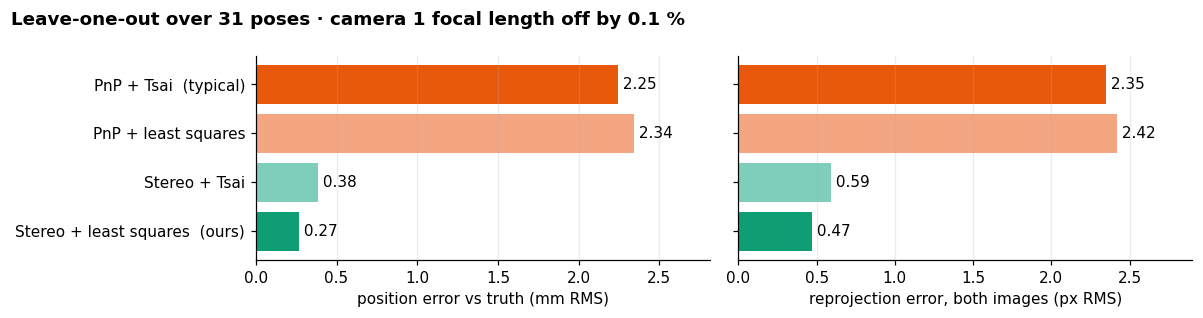

Stereo + least squares: 88% less held-out position error than the typical pipeline


In [11]:
def with_focal_error(rel):
    K = {cam: K_TRUE[cam].copy() for cam in (1, 2)}
    K[1][0, 0] *= 1 + rel
    K[1][1, 1] *= 1 + rel
    return K


K_OFF = with_focal_error(0.001)
B_off = measure(K_OFF)
LOO_OFF = {name: leave_one_out(B_off[m], solver, K_OFF) for name, (m, solver, _) in PIPELINES.items()}
bar_panel(LOO_OFF, "Leave-one-out over 31 poses · camera 1 focal length off by 0.1 %")
gain = 1 - LOO_OFF["Stereo + least squares  (ours)"]["mm"] / LOO_OFF["PnP + Tsai  (typical)"]["mm"]
print(f"Stereo + least squares: {gain:.0%} less held-out position error than the typical pipeline")

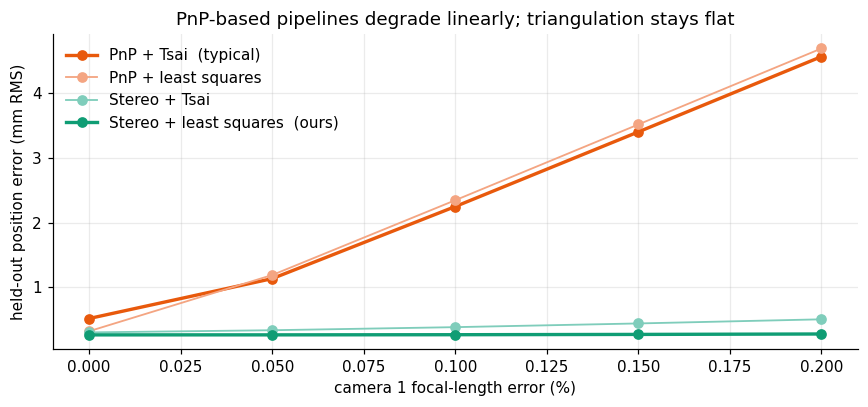

In [12]:
errors = np.array([0, 0.0005, 0.001, 0.0015, 0.002])
sweep = {name: [] for name in PIPELINES}
for rel in errors:
    K_est = with_focal_error(rel)
    Bs = measure(K_est)
    for name, (m, solver, _) in PIPELINES.items():
        sweep[name].append(leave_one_out(Bs[m], solver, K_est)["mm"])

fig, ax = plt.subplots(figsize=(8, 3.8))
for name, (_, _, col) in PIPELINES.items():
    ax.plot(errors * 100, sweep[name], "o-", color=col, lw=2.2 if "typical" in name or "ours" in name else 1.2, label=name)
ax.set_xlabel("camera 1 focal-length error (%)")
ax.set_ylabel("held-out position error (mm RMS)")
ax.set_title("PnP-based pipelines degrade linearly; triangulation stays flat")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 7. Takeaways

* **A single camera measures depth poorly.** PnP's error lies almost entirely along the line of sight,
  and the camera that made the measurement can't see it.
* **If you have two cameras, triangulate.** Measuring each corner from two directions removes the depth
  ambiguity, and it also makes the result much less sensitive to small intrinsics errors.
* **Solve `X` and `Y` together.** A joint least-squares fit over all poses generally beats the closed-form
  pairwise solvers, and it's easy to write with `scipy.optimize.least_squares`.
* **Validate on held-out poses.** Reprojection error on the calibration data itself flatters every
  method. Predict a pose the solver hasn't seen and check it in *both* cameras.

### On the real cell (from the video)

The same comparison on a real two-camera cell (31 poses, stereo RMS 0.24 px, ≈ 2.9 m baseline),
scored by leave-one-out against each method's own measured board pose:

| Pipeline | Held-out position error | Held-out reprojection, both images |
|---|---|---|
| PnP (camera 1) + Tsai | 3.14 mm | 4.52 px |
| PnP (camera 1) + least squares | 1.99 mm | 2.47 px |
| **Stereo + least squares** | **1.36 mm** | **2.24 px** |

That's **57 % less position error** than the typical single-camera pipeline. The real numbers are
higher than the simulation, as expected: real corner detection, lens distortion and robot accuracy are
all worse than the idealised noise model here. The ranking is the same.

### Using this on your own data

Replace the simulated inputs with real ones and the rest of the notebook runs unchanged:

* `A` – flange → base 4×4 transforms from the robot controller (mm),
* `DETECTED[1]`, `DETECTED[2]` – chessboard corners from `cv2.findChessboardCorners` + `cv2.cornerSubPix`,
  **undistorted** with `cv2.undistortPoints(..., P=K)` (this notebook assumes zero distortion),
* `K_TRUE` and `T_CAM2_CAM1` – intrinsics and extrinsics from `cv2.stereoCalibrate`.

Without ground truth, use the leave-one-out **reprojection** error to compare methods.

### References

* R. Tsai, R. Lenz, *A new technique for fully autonomous and efficient 3D robotics hand/eye calibration*, IEEE T-RA 1989.
* OpenCV docs: [`calibrateHandEye`](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html#gaebfc1c9f7434196a374c382abf43439b),
  [`solvePnP`](https://docs.opencv.org/4.x/d5/d1f/calib3d_solvePnP.html),
  [`triangulatePoints`](https://docs.opencv.org/4.x/d0/dbd/group__triangulation.html).